In [75]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features.to_numpy()
y = adult.data.targets.to_numpy()
y = np.where(y.ravel() == '<=50K', -1, 1)

In [76]:
print("Features shape:", X.shape)
print("Targets shape:", y.shape)

print("First 5 feature rows:\n", X[:5])
print("First 5 target values:\n", y[:5])

Features shape: (48842, 14)
Targets shape: (48842,)
First 5 feature rows:
 [[39 'State-gov' 77516 'Bachelors' 13 'Never-married' 'Adm-clerical'
  'Not-in-family' 'White' 'Male' 2174 0 40 'United-States']
 [50 'Self-emp-not-inc' 83311 'Bachelors' 13 'Married-civ-spouse'
  'Exec-managerial' 'Husband' 'White' 'Male' 0 0 13 'United-States']
 [38 'Private' 215646 'HS-grad' 9 'Divorced' 'Handlers-cleaners'
  'Not-in-family' 'White' 'Male' 0 0 40 'United-States']
 [53 'Private' 234721 '11th' 7 'Married-civ-spouse' 'Handlers-cleaners'
  'Husband' 'Black' 'Male' 0 0 40 'United-States']
 [28 'Private' 338409 'Bachelors' 13 'Married-civ-spouse'
  'Prof-specialty' 'Wife' 'Black' 'Female' 0 0 40 'Cuba']]
First 5 target values:
 [-1 -1 -1 -1 -1]


In [77]:
print(np.unique(y))

[-1  1]


In [ ]:
# remove missing values
missing_mask = (X == "?")
rows_with_missing = np.sum(missing_mask, axis = 1) > 0
rows_to_keep = ~rows_with_missing
X = X[rows_to_keep]
y = y[rows_to_keep]

print(X.shape)

In [79]:
features = ["Age",                  # int
            "Workclass",            # categorical
            "Fnlwgt",               # int
            "Education",            # categorical
            "Education Num",        # int
            "Marital Status",       # categorical
            "Occupation",           # categorical
            "Relationship",         # categorical
            "Race",                 # categorical  
            "Sex",                  # categorical   
            "Capital Gain",         # binary categorical
            "Capital Loss",         # int
            "Hours Per Week",       # int
            "Native Country",       # categorical
            "Income"]               # -1/1

In [80]:
# statistics for int features
int_indices = [0, 2, 4, 10, 11]
for i in int_indices:
    print(f"[{features[i]}]")
    feat_data = X[:, i]

    print(f"Mean: {np.mean(feat_data)}")
    print(f"Std: {np.std(feat_data)}")
    print(f"Min: {np.min(feat_data)}")
    print(f"Max: {np.max(feat_data)}\n")

[Age]
Mean: 38.553431087569706
Std: 13.390118320056452
Min: 17
Max: 90

[Fnlwgt]
Mean: 189668.27915939968
Std: 105672.55031383577
Min: 13492
Max: 1490400

[Education Num]
Mean: 10.10434295803458
Std: 2.556210249498046
Min: 1
Max: 16

[Capital Gain]
Mean: 1088.4662489503262
Std: 7468.922299328548
Min: 0
Max: 99999

[Capital Loss]
Mean: 88.20659733436686
Std: 403.8718997871633
Min: 0
Max: 4356



In [81]:
# top 5 counts for categorical features
cat_indices = [1, 3, 5, 6, 7, 8, 9, 10, 13]
for i in cat_indices:
    print(f"[{features[i]}]")

    feat_data = X[:, i].astype(str)

    unique, counts = np.unique(feat_data, return_counts = True)

    indices = np.argsort(counts)[::-1]
    unique = unique[indices]
    counts = counts[indices]

    for i in range(min(5, len(unique))):
        print(f"{i + 1}. {unique[i]}: {counts[i]}")
    
    print()

[Workclass]
1. Private: 33496
2. Self-emp-not-inc: 3820
3. Local-gov: 3110
4. State-gov: 1962
5. Self-emp-inc: 1653

[Education]
1. HS-grad: 15123
2. Some-college: 10265
3. Bachelors: 7714
4. Masters: 2561
5. Assoc-voc: 1986

[Marital Status]
1. Married-civ-spouse: 21468
2. Never-married: 15160
3. Divorced: 6404
4. Separated: 1444
5. Widowed: 1352

[Occupation]
1. Prof-specialty: 6070
2. Craft-repair: 6043
3. Exec-managerial: 6012
4. Adm-clerical: 5562
5. Sales: 5438

[Relationship]
1. Husband: 18986
2. Not-in-family: 12004
3. Own-child: 6979
4. Unmarried: 4891
5. Wife: 2169

[Race]
1. White: 39879
2. Black: 4378
3. Asian-Pac-Islander: 1375
4. Amer-Indian-Eskimo: 445
5. Other: 366

[Sex]
1. Male: 31240
2. Female: 15203

[Capital Gain]
1. 0: 42582
2. 15024: 503
3. 7688: 396
4. 7298: 358
5. 99999: 233

[Native Country]
1. United-States: 42166
2. Mexico: 918
3. Philippines: 285
4. nan: 274
5. Germany: 197



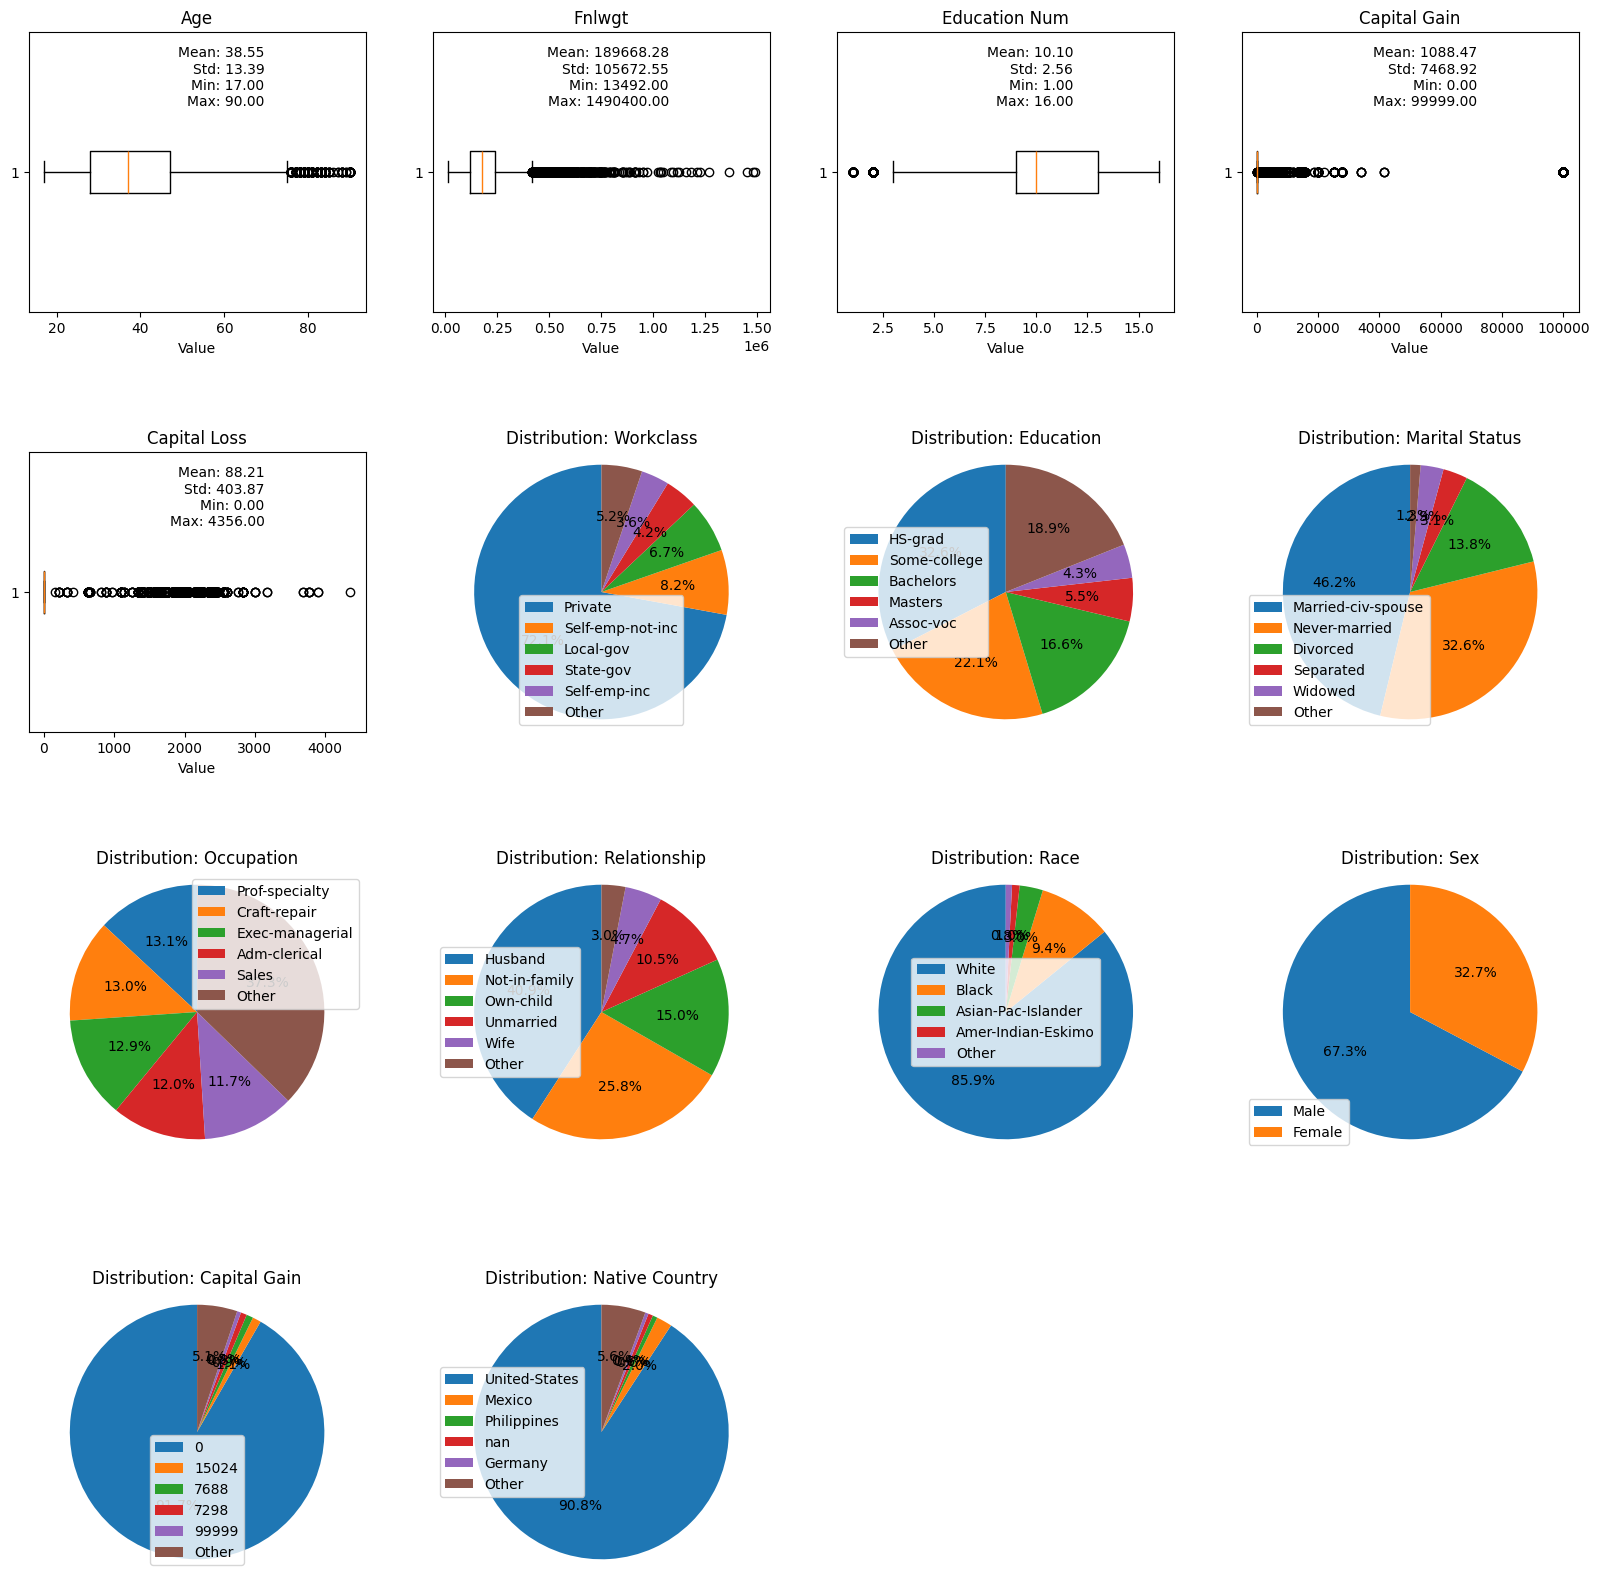

In [82]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
fig.subplots_adjust(hspace = 0.5)
axes = axes.flatten()

plot_idx = 0
# plot the numerical data
for i in range(len(int_indices)):
    feat_idx = int_indices[i]

    feat_data = X[:, feat_idx].astype(float)

    axes[plot_idx].set_title(features[feat_idx], fontsize = 12)
    axes[plot_idx].boxplot(feat_data, vert = False)
    axes[plot_idx].set_xlabel("Value", fontsize = 10)

    stats_text = (f"Mean: {np.mean(feat_data):.2f}\nStd: {np.std(feat_data):.2f}\nMin: {np.min(feat_data):.2f}\nMax: {np.max(feat_data):.2f}")
    axes[plot_idx].text(0.7, 0.95, stats_text, verticalalignment="top", horizontalalignment="right", transform = axes[plot_idx].transAxes)

    plot_idx += 1


# plot the categorical data
for i in range(len(cat_indices)):
    feat_idx = cat_indices[i]

    feat_data = X[:, feat_idx].astype(str)

    unique, counts = np.unique(feat_data, return_counts = True)

    # sort so we take the most common; anything after the first 5 are considered "other"
    indices = np.argsort(counts)[::-1]
    unique = unique[indices]
    counts = counts[indices]

    top_unique = list(unique[:5])
    top_counts = list(counts[:5])

    if len(counts) > 5:
        top_unique.append("Other")
        other_count = np.sum(counts[5:])
        top_counts.append(other_count)
    
    wedges, texts, autotexts = axes[plot_idx].pie(top_counts, autopct = "%1.1f%%", startangle = 90)
    axes[plot_idx].set_title(f"Distribution: {features[feat_idx]}")

    axes[plot_idx].legend(wedges, top_unique)
    axes[plot_idx].axis("equal")

    plot_idx += 1
    
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])
